Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (3200, 141)
Validation shape: (800, 141)
Test shape: (1000, 141)

Training signal shape: (3200, 140)
Validation signal shape: (800, 140)
Final test signal shape: (1000, 140)

Training labels shape: (3200,)
Validation labels shape: (800,)
Final test labels shape: (1000,)

Training class counts:
[1868 1132   61  124   15]

Validation class counts:
[467 282  16  31   4]

Final test class counts:
[584 353  19  39   5]

Transformer input shapes:
Train: (3200, 140, 1)
Validation: (800, 140, 1)
Test: (1000, 140, 1)

Using device: cuda
GPU: Tesla T4

Model has 111,877 trainable parameters.
Epoch:   1 | Train loss: 0.319824 | Val loss: 0.210179 | Best Val loss: 0.210179 | Best epoch: 1 | Time: 0.79 s
Epoch:   2 | Train loss: 0.188274 | Val loss: 0.210042 | Best Val loss: 0.210042 | Best epoch: 2 | Time: 0.85 s
Epoch:   3 | Train loss: 0.173529 | Val loss:

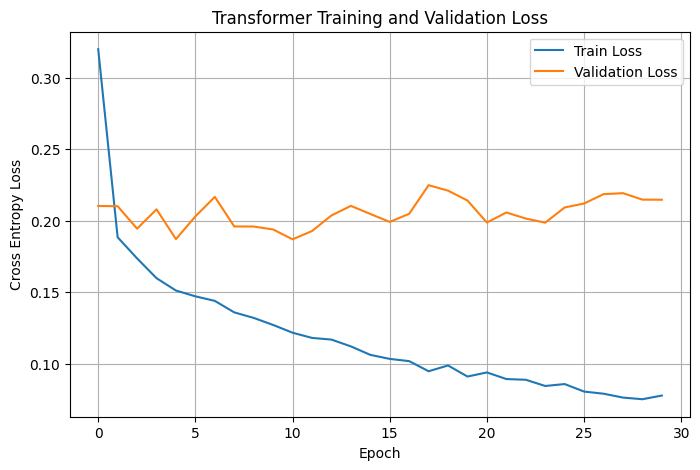


Test Results
Accuracy: 0.9470
Macro F1: 0.6493
Balanced Accuracy: 0.6192

Classification Report:
              precision    recall  f1-score   support

     Class 1     0.9915    0.9949    0.9932       584
     Class 2     0.9264    0.9632    0.9444       353
     Class 3     0.4783    0.5789    0.5238        19
     Class 4     0.6087    0.3590    0.4516        39
     Class 5     1.0000    0.2000    0.3333         5

    accuracy                         0.9470      1000
   macro avg     0.8010    0.6192    0.6493      1000
weighted avg     0.9439    0.9470    0.9426      1000



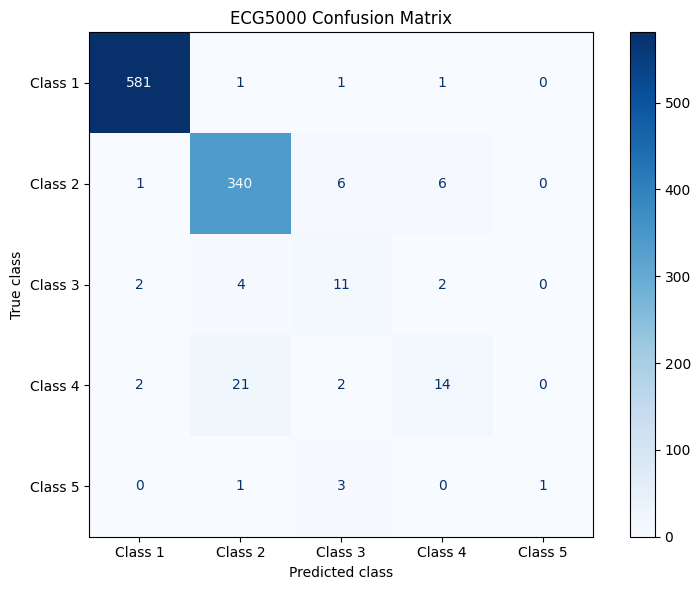

In [ ]:
from google.colab import drive

drive.mount("/content/drive")


import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import time

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


##################################################
### DATASET
##################################################

class ECGDataset(Dataset):

    def __init__(
        self,
        signals: np.ndarray,
        labels: np.ndarray,
    ):

        self.signals = torch.tensor(
            signals,
            dtype=torch.float32
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):

        x = self.signals[idx]
        y = self.labels[idx]

        return x, y


##################################################
### POSITIONAL ENCODING
##################################################

class PositionalEncoding(nn.Module):

    def __init__(
        self,
        d_model: int,
        max_len: int = 1000,
    ):

        super().__init__()

        pe = torch.zeros(
            max_len,
            d_model
        )

        position = torch.arange(
            0,
            max_len,
            dtype=torch.float32
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2
            ).float()
            * (
                -torch.log(
                    torch.tensor(10000.0)
                ) / d_model
            )
        )

        pe[:, 0::2] = torch.sin(
            position * div_term
        )

        pe[:, 1::2] = torch.cos(
            position * div_term
        )

        pe = pe.unsqueeze(0)

        self.register_buffer(
            "pe",
            pe
        )

    def forward(self, x):

        x = x + self.pe[:, :x.size(1)]

        return x


##################################################
### TRANSFORMER CLASSIFIER
##################################################

class TransformerClassifier(nn.Module):

    def __init__(
        self,
        input_size: int,
        d_model: int,
        dim_ff: int,
        n_classes: int,
        num_layers: int,
        n_heads: int,
        dropout: float,
        n_tokens: int,
    ):

        super().__init__()


        # Convert each ECG value from
        # input_size = 1
        # into d_model dimensions

        self.input_projection = nn.Linear(
            input_size,
            d_model
        )


        # Add timestep position information

        self.positional_encoding = PositionalEncoding(
            d_model=d_model,
            max_len=n_tokens
        )


        # Individual Transformer encoder layer

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
        )


        # Stack encoder layers

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )


        # Classification layer

        self.output_projection = nn.Linear(
            d_model * n_tokens,
            n_classes
        )


    def forward(
        self,
        x: torch.Tensor
    ) -> torch.Tensor:


        # x:
        # (batch_size, 140, 1)


        ### Input projection

        x_embed = self.input_projection(
            x
        )

        # (batch_size, 140, d_model)


        ### Positional encoding

        x_embed_pe = self.positional_encoding(
            x_embed
        )


        ### Transformer encoder

        z = self.encoder(
            x_embed_pe
        )

        # z:
        # (batch_size, 140, d_model)


        ### Flatten

        z_flat = z.flatten(
            start_dim=1
        )

        # (batch_size, 140 * d_model)


        ### Classification

        logits = self.output_projection(
            z_flat
        )

        # (batch_size, 5)

        return logits


##################################################
### CONFUSION MATRIX
##################################################

def plot_confusion_matrix(
    true_labels: np.ndarray,
    predicted_labels: np.ndarray,
):

    class_names = [
        "Class 1",
        "Class 2",
        "Class 3",
        "Class 4",
        "Class 5",
    ]


    cm = confusion_matrix(
        true_labels,
        predicted_labels
    )


    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )


    fig, ax = plt.subplots(
        figsize=(8, 6)
    )


    display.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
    )


    plt.xlabel(
        "Predicted class"
    )

    plt.ylabel(
        "True class"
    )

    plt.title(
        "ECG5000 Confusion Matrix"
    )

    plt.tight_layout()

    plt.show()


##################################################
### MAIN
##################################################

def main():


    ##################################################
    ### RANDOM SEEDS
    ##################################################

    torch.manual_seed(42)

    np.random.seed(42)


    ##################################################
    ### LOAD DATA FROM GOOGLE DRIVE
    ##################################################

    DATA_DIR = "/content/drive/MyDrive/TUBerlin_Data"


    train_path = (
        f"{DATA_DIR}/ECG5000_FOLD_1_TRAIN_3200.txt"
    )

    val_path = (
        f"{DATA_DIR}/ECG5000_FOLD_1_VAL_800.txt"
    )

    test_path = (
        f"{DATA_DIR}/ECG5000_FINAL_TEST_1000.txt"
    )



    train_data = np.loadtxt(train_path)
    val_data = np.loadtxt(val_path)
    test_data = np.loadtxt(test_path)


    print("Train shape:", train_data.shape)
    print("Validation shape:", val_data.shape)
    print("Test shape:", test_data.shape)


    ##################################################
    ### SPLIT SIGNALS AND LABELS
    ##################################################

    # First column = class label

    train_labels = train_data[:, 0].astype(int)
    val_labels = val_data[:, 0].astype(int)
    test_labels = test_data[:, 0].astype(int)


    # Remaining 140 columns = ECG waveform

    train_signal = train_data[:, 1:]

    val_signal = val_data[:, 1:]

    test_signal = test_data[:, 1:]


    ##################################################
    ### CHANGE LABELS FROM 1-5 TO 0-4
    ##################################################

    train_labels = train_labels - 1
    val_labels = val_labels - 1
    test_labels = test_labels - 1

    ##################################################
    ### CHECK DATA
    ##################################################


    print("\nTraining signal shape:", train_signal.shape)
    print("Validation signal shape:", val_signal.shape)
    print("Final test signal shape:", test_signal.shape)

    print("\nTraining labels shape:", train_labels.shape)
    print("Validation labels shape:", val_labels.shape)
    print("Final test labels shape:", test_labels.shape)

    print("\nTraining class counts:")
    print(np.bincount(train_labels))

    print("\nValidation class counts:")
    print(np.bincount(val_labels))

    print("\nFinal test class counts:")
    print(np.bincount(test_labels))


    ##################################################
    ### STANDARD SCALING
    ##################################################

    scaler = StandardScaler()


    # Fit scaler ONLY on training data
    scaler.fit(train_signal)



    train_signal_scaled = scaler.transform(
        train_signal
    ).astype(
        np.float32
    )


    val_signal_scaled = scaler.transform(
        val_signal
    ).astype(
        np.float32
    )


    test_signal_scaled = scaler.transform(
        test_signal
    ).astype(
        np.float32
    )


    ##################################################
    ### ADD FEATURE DIMENSION
    ##################################################

    # Current shape:
    #
    # (samples, 140)
    #
    # Transformer requires:
    #
    # (samples, sequence_length, features)
    #
    # Therefore:
    #
    # (samples, 140, 1)


    train_signal_scaled = train_signal_scaled[
        :,
        :,
        np.newaxis
    ]


    val_signal_scaled = val_signal_scaled[
        :,
        :,
        np.newaxis
    ]


    test_signal_scaled = test_signal_scaled[
        :,
        :,
        np.newaxis
    ]


    print(
        "\nTransformer input shapes:"
    )

    print(
        "Train:",
        train_signal_scaled.shape
    )

    print(
        "Validation:",
        val_signal_scaled.shape
    )

    print(
        "Test:",
        test_signal_scaled.shape
    )


    ##################################################
    ### DATASETS
    ##################################################

    train_dataset = ECGDataset(
        signals=train_signal_scaled,
        labels=train_labels,
    )


    val_dataset = ECGDataset(
        signals=val_signal_scaled,
        labels=val_labels,
    )


    test_dataset = ECGDataset(
        signals=test_signal_scaled,
        labels=test_labels,
    )


    ##################################################
    ### DATALOADERS
    ##################################################

    batch_size = 32


    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )


    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )


    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
    )


    ##################################################
    ### TRANSFORMER HYPERPARAMETERS
    ##################################################

    input_size = 1

    d_model = 64

    dim_ff = 128

    n_heads = 4

    num_layers = 2

    dropout = 0.1

    n_tokens = train_signal_scaled.shape[1]

    n_classes = 5

    learning_rate = 0.0001


    ##################################################
    ### DEVICE
    ##################################################

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )


    print(
        "\nUsing device:",
        device
    )


    if torch.cuda.is_available():

        print(
            "GPU:",
            torch.cuda.get_device_name(0)
        )


    ##################################################
    ### INITIALISE MODEL
    ##################################################

    model = TransformerClassifier(
        input_size=input_size,
        d_model=d_model,
        dim_ff=dim_ff,
        n_classes=n_classes,
        num_layers=num_layers,
        n_heads=n_heads,
        dropout=dropout,
        n_tokens=n_tokens,
    ).to(
        device
    )


    ##################################################
    ### NUMBER OF TRAINABLE PARAMETERS
    ##################################################

    num_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


    print(
        f"\nModel has {num_params:,} trainable parameters."
    )


    ##################################################
    ### OPTIMISER
    ##################################################

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )


    ##################################################
    ### LOSS FUNCTION
    ##################################################

    criterion = nn.CrossEntropyLoss()


    ##################################################
    ### TRAINING SETTINGS
    ##################################################

    epochs = 30


    train_losses = []

    val_losses = []

    epoch_times = []


    best_val_loss = float(
        "inf"
    )

    best_val_epoch = 0


    ##################################################
    ### TRAINING LOOP
    ##################################################

    for epoch in range(
        epochs
    ):


        ##################################################
        ### START EPOCH TIMER
        ##################################################

        epoch_start_time = time.time()


        ##################################################
        ### TRAINING PHASE
        ##################################################

        model.train()

        train_loss = 0.0


        for x_batch, y_batch in train_loader:


            x_batch = x_batch.to(
                device
            )

            y_batch = y_batch.to(
                device
            )


            optimizer.zero_grad()


            predictions = model(
                x_batch
            )


            loss = criterion(
                predictions,
                y_batch
            )


            loss.backward()


            optimizer.step()


            train_loss += loss.item()


        train_loss /= len(
            train_loader
        )


        train_losses.append(
            train_loss
        )


        ##################################################
        ### VALIDATION PHASE
        ##################################################

        model.eval()

        val_loss = 0.0


        with torch.no_grad():


            for x_batch, y_batch in val_loader:


                x_batch = x_batch.to(
                    device
                )

                y_batch = y_batch.to(
                    device
                )


                predictions = model(
                    x_batch
                )


                loss = criterion(
                    predictions,
                    y_batch
                )


                val_loss += loss.item()


        val_loss /= len(
            val_loader
        )


        val_losses.append(
            val_loss
        )


        ##################################################
        ### SAVE BEST MODEL
        ##################################################

        if val_loss < best_val_loss:


            best_val_loss = val_loss

            best_val_epoch = epoch


            torch.save(
                model.state_dict(),
                "best_transformer_model.pth"
            )


        ##################################################
        ### EPOCH TIME
        ##################################################

        # Synchronise GPU before stopping timer
        # so CUDA operations are completed.

        if torch.cuda.is_available():

            torch.cuda.synchronize()


        epoch_time = (
            time.time()
            - epoch_start_time
        )


        epoch_times.append(
            epoch_time
        )


        ##################################################
        ### PRINT EPOCH RESULTS
        ##################################################

        print(
            f"Epoch: {epoch + 1:3d} | "
            f"Train loss: {train_loss:.6f} | "
            f"Val loss: {val_loss:.6f} | "
            f"Best Val loss: {best_val_loss:.6f} | "
            f"Best epoch: {best_val_epoch + 1} | "
            f"Time: {epoch_time:.2f} s"
        )


    ##################################################
    ### AVERAGE EPOCH TIME
    ##################################################

    average_epoch_time = np.mean(
        epoch_times
    )


    print(
        f"\nAverage time per epoch: "
        f"{average_epoch_time:.2f} seconds"
    )


    ##################################################
    ### PLOT TRAINING / VALIDATION LOSS
    ##################################################

    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(
        train_losses,
        label="Train Loss"
    )


    plt.plot(
        val_losses,
        label="Validation Loss"
    )


    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Cross Entropy Loss"
    )

    plt.title(
        "Transformer Training and Validation Loss"
    )

    plt.legend()

    plt.grid()

    plt.show()


    ##################################################
    ### LOAD BEST MODEL
    ##################################################

    best_model = TransformerClassifier(
        input_size=input_size,
        d_model=d_model,
        dim_ff=dim_ff,
        n_classes=n_classes,
        num_layers=num_layers,
        n_heads=n_heads,
        dropout=dropout,
        n_tokens=n_tokens,
    ).to(
        device
    )


    best_model.load_state_dict(
        torch.load(
            "best_transformer_model.pth",
            map_location=device
        )
    )


    best_model.eval()


    ##################################################
    ### TEST MODEL
    ##################################################

    all_predictions = []

    all_targets = []


    with torch.no_grad():


        for x_batch, y_batch in test_loader:


            x_batch = x_batch.to(
                device
            )


            logits = best_model(
                x_batch
            )


            predicted_classes = torch.argmax(
                logits,
                dim=1
            )


            all_predictions.extend(
                predicted_classes
                .cpu()
                .numpy()
            )


            all_targets.extend(
                y_batch.numpy()
            )


    all_predictions = np.array(
        all_predictions
    )


    all_targets = np.array(
        all_targets
    )


    ##################################################
    ### EVALUATION METRICS
    ##################################################

    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )


    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro"
    )


    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )


    ##################################################
    ### PRINT TEST RESULTS
    ##################################################

    print(
        "\nTest Results"
    )


    print(
        f"Accuracy: "
        f"{accuracy:.4f}"
    )


    print(
        f"Macro F1: "
        f"{macro_f1:.4f}"
    )


    print(
        f"Balanced Accuracy: "
        f"{balanced_accuracy:.4f}"
    )


    print(
        "\nClassification Report:"
    )


    print(
        classification_report(
            all_targets,
            all_predictions,
            target_names=[
                "Class 1",
                "Class 2",
                "Class 3",
                "Class 4",
                "Class 5",
            ],
            digits=4,
        )
    )


    ##################################################
    ### CONFUSION MATRIX
    ##################################################

    plot_confusion_matrix(
        all_targets,
        all_predictions
    )


if __name__ == "__main__":

    main()
